In [1]:
import os

import IPython.display as ipd
import librosa
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
audio_sets_path = os.path.join(os.path.dirname(os.getcwd()), 'Phonetics Project (Praat)')
audio_sets_path

'/home/alexeysvatov/МИСИС/ProjectLinguist/jupyter/Phonetics Project (Praat)'

In [3]:
in_a_restaurant_path = os.path.join(audio_sets_path, '1_In a restaurant.mp3')
in_a_restaurant_path

'/home/alexeysvatov/МИСИС/ProjectLinguist/jupyter/Phonetics Project (Praat)/1_In a restaurant.mp3'

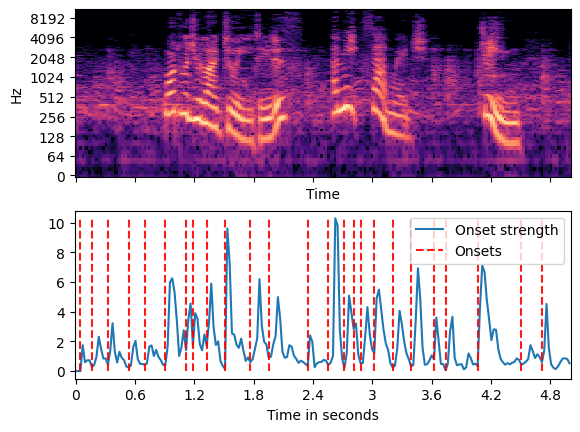

In [4]:
y, sr = librosa.load(in_a_restaurant_path, offset=5, duration=5)

onset_envelope = librosa.onset.onset_strength(y=y, sr=sr)
onsets = librosa.onset.onset_detect(onset_envelope=onset_envelope)
 
librosa.onset.onset_detect(y=y, sr=sr, units='time')
 
D = np.abs(librosa.stft(y))
fig, ax = plt.subplots(nrows=2, sharex=True)
librosa.display.specshow(librosa.amplitude_to_db(D, ref=np.max), x_axis='time', y_axis='log', ax=ax[0])
 
o_env = librosa.onset.onset_strength(y=y, sr=sr)
times = librosa.times_like(o_env, sr=sr)
onset_frames = librosa.onset.onset_detect(
    onset_envelope=o_env, 
    sr=sr, 
    backtrack=True, 
)
 
ax[1].plot(times, o_env, label='Onset strength')
ax[1].vlines(times[onset_frames], 0, o_env.max(), color='r', alpha=0.9,
           linestyle='--', label='Onsets')

ax[1].legend()
plt.xlabel("Time in seconds")
plt.show()
ipd.Audio(data=y, rate=sr)

In [5]:
len(onset_frames)

25

In [6]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

y, sr = librosa.load(in_a_restaurant_path, offset=5, duration=5)

# Calcualte the onset frames in the usual way
o_env = librosa.onset.onset_strength(y=y, sr=sr)
times = librosa.times_like(o_env, sr=sr)
onstm = librosa.onset.onset_detect(
    y=y, 
    sr=sr, 
    units='time', 
    backtrack=True, 
)

# Calculate RMS energy per frame.  I shortened the frame length from the
# default value in order to avoid ending up with too much smoothing
rms = librosa.feature.rms(y=y, frame_length=512)[0]
envtm = librosa.frames_to_time(np.arange(len(rms)), sr=sr)

# Use final 0.01 seconds of recording in order to estimate median noise level
# and typical variation
noiseidx = envtm < envtm[10]
noisemedian = np.percentile(rms[noiseidx], 50)
sigma = np.percentile(rms[noiseidx], 84.1) - noisemedian

# Set the minimum RMS energy threshold that is needed in order to declare
# an "onset" event to be equal to 5 sigma above the median
threshold = noisemedian + 5 * sigma
threshidx = rms > threshold

# Choose the corrected onset times as only those which meet the RMS energy
# minimum threshold requirement
correctedonstm = onstm[[tm in envtm[threshidx] for tm in onstm]]

In [7]:
rms[noiseidx]

array([0.00763672, 0.01336091, 0.01427594, 0.01334631, 0.01641894,
       0.00970225, 0.00925213, 0.0074946 , 0.00932967, 0.01304674],
      dtype=float32)

In [8]:
correctedonstm

array([0.90557823, 1.11455782, 1.18421769, 1.32353741, 1.50929705,
       1.76471655, 1.95047619, 2.71673469, 2.80961451, 3.0185941 ,
       3.20435374])

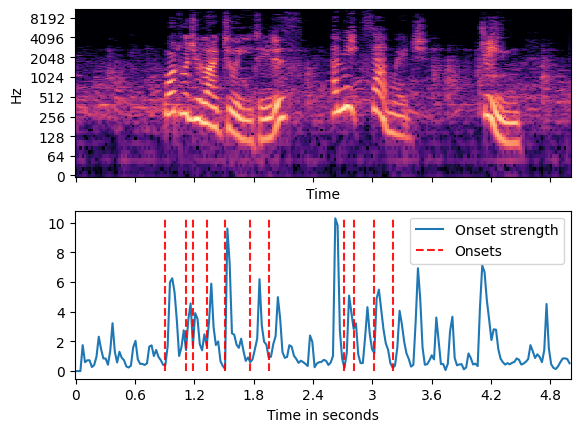

In [9]:
fig, ax = plt.subplots(nrows=2, sharex=True)
librosa.display.specshow(librosa.amplitude_to_db(D, ref=np.max), x_axis='time', y_axis='log', ax=ax[0])  # ИСТИНА ГДЕ-ТО РЯДОМ
ax[1].plot(times, o_env, label='Onset strength')
ax[1].vlines(correctedonstm, 0, o_env.max(), color='r', alpha=0.9,
           linestyle='--', label='Onsets')

ax[1].legend()
plt.xlabel("Time in seconds")
plt.show()
ipd.Audio(data=y, rate=sr)